# Chapter 4.7: Listwise & Context-aware Ranking

## Learning Objectives

By the end of this notebook, you will be able to:

1. Implement **PRM** (Personalized Re-ranking Model, Alibaba) with cross-item attention
2. Build **SetRank** for permutation-equivariant listwise ranking
3. Design context-aware re-ranking models that capture item interactions within a list
4. Implement diversity-aware re-ranking: **MMR** and **DPP**
5. Optimize slates considering **position** and **context effects**
6. Evaluate listwise ranking metrics (NDCG, MAP, diversity)
7. Balance relevance and diversity in ranked lists

## Prerequisites

- Understanding of pointwise and pairwise ranking losses
- Familiarity with Transformer/attention mechanisms
- Basic knowledge of information retrieval metrics

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part4/chapter_4.7_listwise_ranking.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part4/chapter_4.7_listwise_ranking.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import List, Optional, Tuple

torch.manual_seed(42)
np.random.seed(42)

print(f"PyTorch version: {torch.__version__}")
device = torch.device('cpu')

PyTorch version: 2.2.2


## 1. From Pointwise to Listwise Ranking

Standard ranking scores items independently (pointwise). But the utility of an item depends on other items in the list:

- **Redundancy**: Two similar items are less useful than two diverse ones
- **Context effects**: An item's perceived quality depends on its neighbors
- **Position bias**: Users attend more to top positions

### Ranking Paradigms

| Paradigm | Input | Output | Models |
|----------|-------|--------|--------|
| Pointwise | Single item | Relevance score | CTR models |
| Pairwise | Item pair | Preference order | RankNet, LambdaRank |
| Listwise | Item list | Permutation/scores | ListNet, PRM, SetRank |

> **💡 Concept:** Re-ranking (listwise) sits after the initial ranking stage. It takes a candidate list of ~100 items and produces the final ordered list of ~10-20 items, considering cross-item interactions.

In [2]:
def generate_reranking_data(num_queries=1000, list_size=20, embed_dim=32,
                             num_categories=10, seed=42):
    """Generate synthetic re-ranking data.
    
    Each query has a candidate list of items with:
    - Initial relevance scores (from first-stage ranker)
    - Item embeddings
    - Category labels
    - Ground-truth relevance labels (binary or graded)
    """
    np.random.seed(seed)
    
    item_embeds = np.random.randn(num_queries, list_size, embed_dim).astype(np.float32)
    categories = np.random.randint(0, num_categories, (num_queries, list_size))
    
    # Initial scores from first-stage ranker (noisy)
    true_relevance = np.random.rand(num_queries, list_size).astype(np.float32)
    initial_scores = true_relevance + np.random.randn(num_queries, list_size).astype(np.float32) * 0.3
    
    # Add diversity bonus: items from underrepresented categories are more valuable
    for q in range(num_queries):
        cat_counts = np.bincount(categories[q], minlength=num_categories)
        for i in range(list_size):
            # Reduce relevance for redundant items
            if cat_counts[categories[q, i]] > 2:
                true_relevance[q, i] *= 0.7
    
    # Graded labels (0-4)
    labels = np.round(true_relevance * 4).astype(np.int64)
    
    return {
        'item_embeds': torch.FloatTensor(item_embeds),
        'categories': torch.LongTensor(categories),
        'initial_scores': torch.FloatTensor(initial_scores),
        'labels': torch.LongTensor(labels),
        'true_relevance': torch.FloatTensor(true_relevance)
    }


EMBED_DIM = 32
LIST_SIZE = 20
NUM_CATEGORIES = 10

rerank_data = generate_reranking_data()
print(f"Queries: {rerank_data['item_embeds'].shape[0]}")
print(f"List size: {rerank_data['item_embeds'].shape[1]}")
print(f"Label distribution: {np.bincount(rerank_data['labels'].numpy().flatten())}")

Queries: 1000
List size: 20
Label distribution: [3018 6188 6250 3458 1086]


## 2. PRM: Personalized Re-ranking Model (Alibaba)

PRM uses a **Transformer encoder** to model cross-item interactions within a candidate list. Each item attends to all other items, allowing the model to detect redundancy and complementarity.

### Architecture

$$\mathbf{H} = \text{TransformerEncoder}([\mathbf{e}_1, \mathbf{e}_2, \ldots, \mathbf{e}_n])$$
$$s_i = \text{MLP}(\mathbf{h}_i)$$

The Transformer's self-attention naturally captures:
- **Item similarity**: Similar items will have high attention weights
- **Redundancy**: The model can learn to down-weight redundant items
- **Complementarity**: Items that complement each other get boosted

> **🔑 Pro Tip:** PRM's key insight is that the Transformer's self-attention serves as an implicit diversity mechanism — it allows each item's score to depend on the entire list context.

In [3]:
class PRM(nn.Module):
    """Personalized Re-ranking Model with cross-item Transformer."""
    def __init__(self, embed_dim: int, num_heads: int = 4,
                 num_layers: int = 2, max_list_size: int = 50):
        super().__init__()
        self.embed_dim = embed_dim
        
        # Position encoding for list positions
        self.position_embedding = nn.Embedding(max_list_size, embed_dim)
        
        # Initial score projection
        self.score_proj = nn.Linear(1, embed_dim)
        
        # Input projection
        self.input_proj = nn.Linear(embed_dim * 2, embed_dim)
        
        # Transformer for cross-item attention
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Score prediction head
        self.score_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1)
        )
    
    def forward(self, item_embeds: torch.Tensor, initial_scores: torch.Tensor) -> torch.Tensor:
        """
        Args:
            item_embeds: (batch, list_size, embed_dim) item features
            initial_scores: (batch, list_size) initial ranking scores
        Returns:
            re_ranked_scores: (batch, list_size)
        """
        batch_size, list_size, _ = item_embeds.shape
        
        # Add position information
        positions = torch.arange(list_size, device=item_embeds.device).unsqueeze(0).expand(batch_size, -1)
        pos_embeds = self.position_embedding(positions)
        
        # Combine item features with initial scores
        score_embeds = self.score_proj(initial_scores.unsqueeze(-1))
        x = self.input_proj(torch.cat([item_embeds + pos_embeds, score_embeds], dim=-1))
        
        # Cross-item attention
        h = self.transformer(x)
        
        # Predict re-ranked scores
        scores = self.score_head(h).squeeze(-1)  # (batch, list_size)
        return scores


prm_model = PRM(EMBED_DIM)
scores = prm_model(rerank_data['item_embeds'][:16], rerank_data['initial_scores'][:16])
print(f"PRM output shape: {scores.shape}")
print(f"PRM parameters: {sum(p.numel() for p in prm_model.parameters()):,}")

PRM output shape: torch.Size([16, 20])
PRM parameters: 29,697


## 3. SetRank: Permutation-Equivariant Ranking

SetRank ensures that the ranking function is **permutation-equivariant**: the output ranking should not depend on the input ordering.

$$f(\pi(\mathbf{X})) = \pi(f(\mathbf{X}))$$

This is achieved by using self-attention (which is naturally permutation-equivariant) without position embeddings.

> **⚠️ Common Pitfall:** Adding position embeddings breaks permutation equivariance. PRM uses position embeddings (trading equivariance for position awareness), while SetRank omits them.

In [4]:
class SetRank(nn.Module):
    """Permutation-equivariant listwise ranking with self-attention."""
    def __init__(self, embed_dim: int, num_heads: int = 4, num_layers: int = 2):
        super().__init__()
        # No position embeddings for permutation equivariance
        self.score_proj = nn.Linear(1, embed_dim)
        self.input_proj = nn.Linear(embed_dim * 2, embed_dim)
        
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads, dim_feedforward=embed_dim * 4,
            dropout=0.1, batch_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        self.score_head = nn.Sequential(
            nn.Linear(embed_dim, embed_dim // 2),
            nn.ReLU(),
            nn.Linear(embed_dim // 2, 1)
        )
    
    def forward(self, item_embeds, initial_scores):
        score_embeds = self.score_proj(initial_scores.unsqueeze(-1))
        x = self.input_proj(torch.cat([item_embeds, score_embeds], dim=-1))
        h = self.transformer(x)
        return self.score_head(h).squeeze(-1)


# Verify permutation equivariance
setrank = SetRank(EMBED_DIM)
setrank.eval()

items = rerank_data['item_embeds'][:1]  # Single query
scores = rerank_data['initial_scores'][:1]

with torch.no_grad():
    out1 = setrank(items, scores)
    
    # Permute input
    perm = torch.randperm(LIST_SIZE)
    out2 = setrank(items[:, perm], scores[:, perm])
    
    # Check: out2 should be a permutation of out1
    out1_permuted = out1[:, perm]
    diff = (out1_permuted - out2).abs().max().item()
    print(f"Permutation equivariance check: max diff = {diff:.6f}")
    print(f"Is permutation-equivariant: {diff < 1e-5}")

Permutation equivariance check: max diff = 0.000000
Is permutation-equivariant: True


## 4. Training Re-ranking Models

### Listwise Losses

**ListNet loss**: Minimize KL divergence between predicted and true relevance distributions.

$$\mathcal{L} = -\sum_i \frac{\exp(y_i)}{\sum_j \exp(y_j)} \log \frac{\exp(s_i)}{\sum_j \exp(s_j)}$$

**ApproxNDCG**: Differentiable approximation of NDCG.

In [5]:
def listnet_loss(predicted_scores, true_relevance):
    """ListNet loss: cross-entropy between score distributions."""
    pred_probs = F.softmax(predicted_scores, dim=-1)
    true_probs = F.softmax(true_relevance, dim=-1)
    return -(true_probs * torch.log(pred_probs + 1e-10)).sum(dim=-1).mean()


def approx_ndcg_loss(predicted_scores, true_relevance, temperature=1.0):
    """Approximate NDCG loss using softmax-based position estimation."""
    # Approximate ranks using softmax
    approx_ranks = torch.softmax(-predicted_scores / temperature, dim=-1)
    # Discounts based on approximate positions
    list_size = predicted_scores.size(-1)
    positions = torch.arange(1, list_size + 1, device=predicted_scores.device, dtype=torch.float32)
    discounts = 1.0 / torch.log2(positions + 1)
    
    # Approximate DCG
    gains = (2 ** true_relevance - 1).float()
    approx_dcg = (gains * (approx_ranks @ discounts.unsqueeze(-1)).squeeze(-1)).sum(dim=-1)
    
    # Ideal DCG
    sorted_gains, _ = gains.sort(dim=-1, descending=True)
    ideal_dcg = (sorted_gains * discounts[:list_size]).sum(dim=-1).clamp(min=1e-10)
    
    return -(approx_dcg / ideal_dcg).mean()


def compute_ndcg(predicted_scores, true_relevance, k=10):
    """Compute NDCG@k."""
    batch_size = predicted_scores.size(0)
    _, sorted_indices = predicted_scores.sort(dim=-1, descending=True)
    sorted_relevance = torch.gather(true_relevance, 1, sorted_indices)
    
    positions = torch.arange(1, k + 1, dtype=torch.float32)
    discounts = 1.0 / torch.log2(positions + 1)
    
    dcg = (sorted_relevance[:, :k].float() * discounts).sum(dim=-1)
    
    ideal_sorted, _ = true_relevance.sort(dim=-1, descending=True)
    ideal_dcg = (ideal_sorted[:, :k].float() * discounts).sum(dim=-1).clamp(min=1e-10)
    
    return (dcg / ideal_dcg).mean().item()


def train_reranker(model, data, epochs=20, batch_size=64, lr=1e-3, loss_fn='listnet'):
    """Train a re-ranking model."""
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    n = data['item_embeds'].size(0)
    history = {'loss': [], 'ndcg@5': [], 'ndcg@10': []}
    
    for epoch in range(epochs):
        model.train()
        perm = torch.randperm(n)
        total_loss = 0
        count = 0
        
        for i in range(0, n, batch_size):
            idx = perm[i:i+batch_size]
            pred_scores = model(data['item_embeds'][idx], data['initial_scores'][idx])
            
            if loss_fn == 'listnet':
                loss = listnet_loss(pred_scores, data['true_relevance'][idx])
            else:
                loss = approx_ndcg_loss(pred_scores, data['labels'][idx].float())
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item()
            count += 1
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            all_scores = model(data['item_embeds'], data['initial_scores'])
            ndcg5 = compute_ndcg(all_scores, data['labels'], k=5)
            ndcg10 = compute_ndcg(all_scores, data['labels'], k=10)
        
        history['loss'].append(total_loss / count)
        history['ndcg@5'].append(ndcg5)
        history['ndcg@10'].append(ndcg10)
    
    return history


# Train PRM and SetRank
torch.manual_seed(42)
prm = PRM(EMBED_DIM)
prm_history = train_reranker(prm, rerank_data)

torch.manual_seed(42)
sr = SetRank(EMBED_DIM)
sr_history = train_reranker(sr, rerank_data)

# Baseline: initial scores
baseline_ndcg5 = compute_ndcg(rerank_data['initial_scores'], rerank_data['labels'], k=5)
baseline_ndcg10 = compute_ndcg(rerank_data['initial_scores'], rerank_data['labels'], k=10)

print(f"\nResults (NDCG@5 / NDCG@10):")
print(f"  Initial scores: {baseline_ndcg5:.4f} / {baseline_ndcg10:.4f}")
print(f"  PRM:            {prm_history['ndcg@5'][-1]:.4f} / {prm_history['ndcg@10'][-1]:.4f}")
print(f"  SetRank:        {sr_history['ndcg@5'][-1]:.4f} / {sr_history['ndcg@10'][-1]:.4f}")


Results (NDCG@5 / NDCG@10):
  Initial scores: 0.8214 / 0.8605
  PRM:            0.8274 / 0.8657
  SetRank:        0.8303 / 0.8668


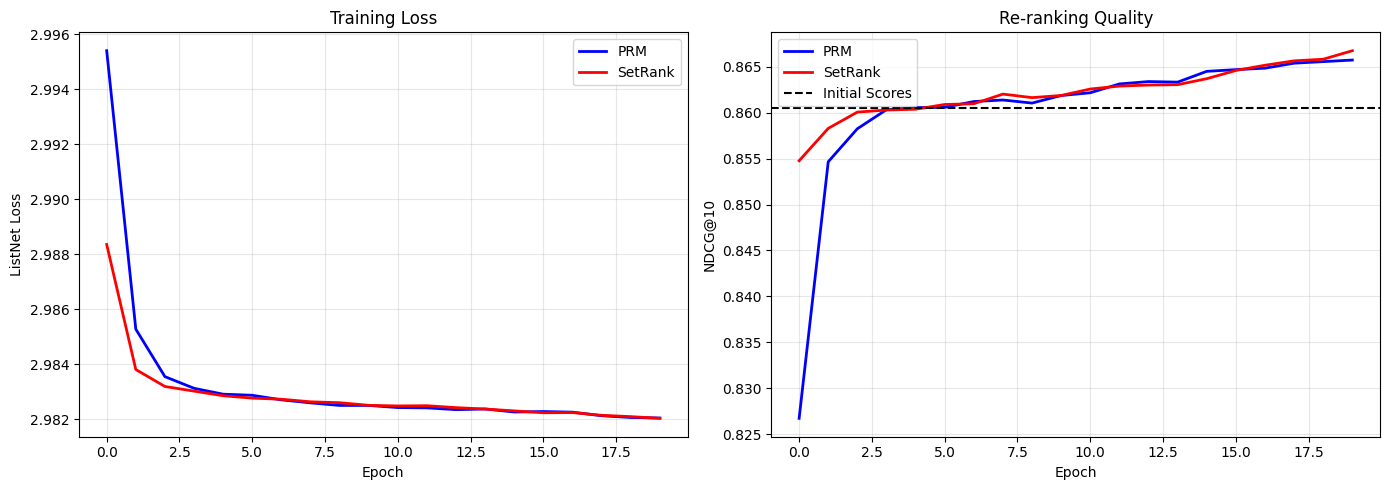

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(prm_history['loss'], 'b-', label='PRM', linewidth=2)
axes[0].plot(sr_history['loss'], 'r-', label='SetRank', linewidth=2)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('ListNet Loss')
axes[0].set_title('Training Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(prm_history['ndcg@10'], 'b-', label='PRM', linewidth=2)
axes[1].plot(sr_history['ndcg@10'], 'r-', label='SetRank', linewidth=2)
axes[1].axhline(y=baseline_ndcg10, color='k', linestyle='--', label='Initial Scores')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('NDCG@10')
axes[1].set_title('Re-ranking Quality')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Diversity-Aware Re-ranking

### 5.1 MMR (Maximal Marginal Relevance)

MMR greedily selects items that balance relevance and diversity:

$$\text{MMR} = \arg\max_{d_i \in R \setminus S} \left[ \lambda \cdot \text{Rel}(d_i) - (1-\lambda) \cdot \max_{d_j \in S} \text{Sim}(d_i, d_j) \right]$$

### 5.2 DPP (Determinantal Point Process)

DPP models both quality and diversity through a kernel matrix:

$$P(S) \propto \det(L_S)$$

where $L_S$ is the submatrix of the kernel $L$ indexed by the selected set $S$. The kernel encodes both item quality and inter-item similarity.

In [7]:
def mmr_rerank(scores: np.ndarray, embeddings: np.ndarray,
               k: int = 10, lambda_param: float = 0.5) -> List[int]:
    """Maximal Marginal Relevance re-ranking.
    
    Args:
        scores: (n,) relevance scores
        embeddings: (n, d) item embeddings
        k: number of items to select
        lambda_param: trade-off between relevance and diversity
    Returns:
        selected: list of k selected indices
    """
    n = len(scores)
    # Normalize embeddings for cosine similarity
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)
    normalized = embeddings / norms
    similarity = normalized @ normalized.T
    
    # Normalize scores to [0, 1]
    if scores.max() > scores.min():
        norm_scores = (scores - scores.min()) / (scores.max() - scores.min())
    else:
        norm_scores = np.ones_like(scores) * 0.5
    
    selected = []
    remaining = list(range(n))
    
    for _ in range(min(k, n)):
        if not remaining:
            break
        
        if not selected:
            # First item: select most relevant
            best = max(remaining, key=lambda i: norm_scores[i])
        else:
            # MMR criterion
            mmr_scores = []
            for i in remaining:
                max_sim = max(similarity[i, j] for j in selected)
                mmr = lambda_param * norm_scores[i] - (1 - lambda_param) * max_sim
                mmr_scores.append(mmr)
            best = remaining[np.argmax(mmr_scores)]
        
        selected.append(best)
        remaining.remove(best)
    
    return selected


def dpp_rerank(scores: np.ndarray, embeddings: np.ndarray,
               k: int = 10) -> List[int]:
    """DPP-based re-ranking using greedy MAP inference.
    
    Constructs kernel L = diag(q) * S * diag(q)
    where q are quality scores and S is similarity.
    """
    n = len(scores)
    # Quality scores
    q = np.exp(scores - scores.max())  # Softmax-like quality
    
    # Similarity matrix
    norms = np.linalg.norm(embeddings, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)
    normalized = embeddings / norms
    S = normalized @ normalized.T
    
    # DPP kernel
    L = np.outer(q, q) * S
    
    # Greedy MAP inference
    selected = []
    remaining = list(range(n))
    
    for _ in range(min(k, n)):
        if not remaining:
            break
        
        best_idx = None
        best_gain = -float('inf')
        
        for i in remaining:
            candidate = selected + [i]
            L_sub = L[np.ix_(candidate, candidate)]
            # Log-det gain (greedy)
            try:
                gain = np.log(max(np.linalg.det(L_sub), 1e-30))
            except np.linalg.LinAlgError:
                gain = -float('inf')
            if gain > best_gain:
                best_gain = gain
                best_idx = i
        
        if best_idx is not None:
            selected.append(best_idx)
            remaining.remove(best_idx)
    
    return selected


# Compare diversity metrics
def compute_diversity(selected_indices, categories, embeddings):
    """Compute diversity metrics for a selected list."""
    sel_cats = categories[selected_indices]
    sel_embeds = embeddings[selected_indices]
    
    # Category diversity: number of unique categories
    cat_diversity = len(np.unique(sel_cats))
    
    # Embedding diversity: average pairwise distance
    norms = np.linalg.norm(sel_embeds, axis=1, keepdims=True)
    norms = np.maximum(norms, 1e-8)
    normalized = sel_embeds / norms
    sims = normalized @ normalized.T
    n = len(selected_indices)
    if n > 1:
        avg_sim = (sims.sum() - n) / (n * (n - 1))
    else:
        avg_sim = 0
    
    return cat_diversity, 1 - avg_sim  # Higher = more diverse


# Compare methods on a sample query
q_idx = 0
q_scores = rerank_data['initial_scores'][q_idx].numpy()
q_embeds = rerank_data['item_embeds'][q_idx].numpy()
q_cats = rerank_data['categories'][q_idx].numpy()
q_labels = rerank_data['labels'][q_idx].numpy()

k = 10
top_k = np.argsort(-q_scores)[:k].tolist()
mmr_50 = mmr_rerank(q_scores, q_embeds, k=k, lambda_param=0.5)
mmr_30 = mmr_rerank(q_scores, q_embeds, k=k, lambda_param=0.3)
dpp_sel = dpp_rerank(q_scores, q_embeds, k=k)

print(f"{'Method':<15} {'Avg Relevance':>15} {'Cat Diversity':>14} {'Embed Diversity':>16}")
print("-" * 62)
for name, sel in [('Top-K', top_k), ('MMR (0.5)', mmr_50), ('MMR (0.3)', mmr_30), ('DPP', dpp_sel)]:
    avg_rel = q_labels[sel].mean()
    cat_div, emb_div = compute_diversity(sel, q_cats, q_embeds)
    print(f"{name:<15} {avg_rel:>15.3f} {cat_div:>14} {emb_div:>16.3f}")

Method            Avg Relevance  Cat Diversity  Embed Diversity
--------------------------------------------------------------
Top-K                     2.000              6            1.031
MMR (0.5)                 2.000              6            1.031
MMR (0.3)                 2.000              6            1.021
DPP                       1.900              6            0.999


## 6. Slate Optimization: Position and Context Effects

In real-world ranking, items at different positions receive different amounts of attention. Position bias must be modeled explicitly.

### Position Bias Model

$$P(\text{click} | i, \text{pos}) = P(\text{examine} | \text{pos}) \cdot P(\text{click} | i, \text{examine})$$

> **💡 Concept:** Optimizing a slate (ordered list) is NP-hard in general, but greedy algorithms with position-aware scoring often achieve near-optimal results in practice.

In [8]:
class PositionAwareReranker(nn.Module):
    """Re-ranking model that explicitly models position effects."""
    def __init__(self, embed_dim: int, max_positions: int = 20):
        super().__init__()
        # Position bias (examination probability)
        self.position_bias = nn.Parameter(torch.zeros(max_positions))
        nn.init.constant_(self.position_bias, 0.0)
        
        # Context-aware scoring
        self.context_attention = nn.MultiheadAttention(
            embed_dim, num_heads=4, batch_first=True
        )
        self.score_head = nn.Sequential(
            nn.Linear(embed_dim * 2, 64),
            nn.ReLU(),
            nn.Linear(64, 1)
        )
    
    def forward(self, item_embeds, initial_scores):
        batch_size, list_size, _ = item_embeds.shape
        
        # Context-aware representations
        context_embeds, attn_weights = self.context_attention(
            item_embeds, item_embeds, item_embeds
        )
        
        # Combine original and context-aware embeddings
        combined = torch.cat([item_embeds, context_embeds], dim=-1)
        item_scores = self.score_head(combined).squeeze(-1)  # (batch, list_size)
        
        # Add position bias (examination probability in log space)
        pos_bias = torch.sigmoid(self.position_bias[:list_size])  # (list_size,)
        
        return item_scores, pos_bias, attn_weights


pos_reranker = PositionAwareReranker(EMBED_DIM)
item_scores, pos_bias, attn = pos_reranker(
    rerank_data['item_embeds'][:8],
    rerank_data['initial_scores'][:8]
)
print(f"Item scores shape: {item_scores.shape}")
print(f"Position bias (learned examination probs): {pos_bias[:10].detach().numpy().round(3)}")

Item scores shape: torch.Size([8, 20])
Position bias (learned examination probs): [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


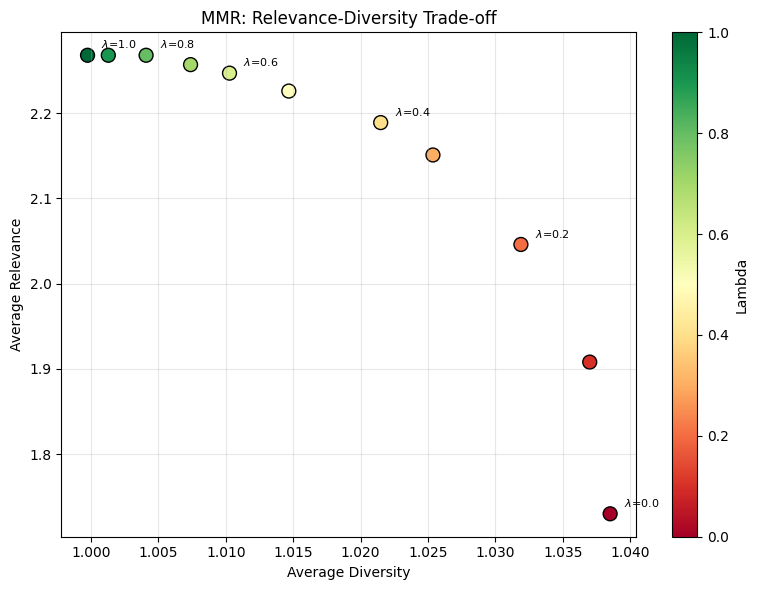

In [9]:
# Visualize diversity-relevance trade-off across lambda values
lambdas = np.arange(0.0, 1.05, 0.1)
avg_relevances = []
avg_diversities = []

for lam in lambdas:
    rels = []
    divs = []
    for q in range(min(100, len(rerank_data['labels']))):
        sel = mmr_rerank(
            rerank_data['initial_scores'][q].numpy(),
            rerank_data['item_embeds'][q].numpy(),
            k=10, lambda_param=lam
        )
        rels.append(rerank_data['labels'][q].numpy()[sel].mean())
        _, div = compute_diversity(
            sel, rerank_data['categories'][q].numpy(),
            rerank_data['item_embeds'][q].numpy()
        )
        divs.append(div)
    avg_relevances.append(np.mean(rels))
    avg_diversities.append(np.mean(divs))

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(avg_diversities, avg_relevances, c=lambdas, cmap='RdYlGn',
                     s=100, edgecolors='black', linewidth=1)
for i, lam in enumerate(lambdas):
    if i % 2 == 0:
        ax.annotate(f'$\\lambda$={lam:.1f}', (avg_diversities[i], avg_relevances[i]),
                    textcoords="offset points", xytext=(10, 5), fontsize=8)

ax.set_xlabel('Average Diversity')
ax.set_ylabel('Average Relevance')
ax.set_title('MMR: Relevance-Diversity Trade-off')
plt.colorbar(scatter, label='Lambda')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Exercises

### 🏋️ Exercise 1: Implement PRM-style Re-ranking with Cross-Item Transformer

Extend PRM to include user features and category-aware cross-item attention.

In [10]:
class EnhancedPRM(nn.Module):
    """Enhanced PRM with user context and category awareness.
    
    Architecture:
    - User embedding injected as a [CLS]-like token
    - Category embeddings added to item representations
    - Multi-layer Transformer encoder for cross-item attention
    - Residual connection from initial scores
    """
    def __init__(self, embed_dim, num_categories, num_heads=4, num_layers=2):
        super().__init__()
        # TODO: Implement enhanced PRM
        # 1. Category embedding
        # 2. User context token
        # 3. Cross-item Transformer
        # 4. Score prediction with residual from initial scores
        pass
    
    def forward(self, item_embeds, categories, initial_scores, user_embed=None):
        # TODO: Implement forward pass
        pass


# TODO: Train and evaluate enhanced PRM, compare with basic PRM

### 🏋️ Exercise 2: Implement Differentiable DPP

Make DPP re-ranking differentiable for end-to-end training.

In [11]:
class DifferentiableDPP(nn.Module):
    """End-to-end trainable DPP for re-ranking.
    
    Uses a continuous relaxation of the DPP objective:
    L = diag(q) * S * diag(q)
    where q = f(items) are learned quality scores.
    
    Maximize: log det(L_S + epsilon * I) for selected set S.
    
    TODO:
    1. Learn quality scores from item features
    2. Compute DPP kernel
    3. Use Gumbel-softmax for differentiable subset selection
    4. Train end-to-end with relevance + diversity objective
    """
    def __init__(self, embed_dim):
        super().__init__()
        # TODO: Implement differentiable DPP
        pass
    
    def forward(self, item_embeds, initial_scores):
        # TODO: Compute DPP scores
        pass

### 🏋️ Exercise 3: Evaluate Re-ranking with Multiple Metrics

Implement a comprehensive evaluation that measures both relevance and diversity.

In [12]:
def comprehensive_evaluation(reranker, data, k_values=[5, 10, 20]):
    """Evaluate re-ranking model with multiple metrics.
    
    Metrics:
    - NDCG@k: Ranking quality
    - ILD (Intra-List Diversity): Average pairwise distance
    - Coverage: Fraction of unique categories
    - Alpha-NDCG: Diversity-aware NDCG
    - Novelty: Average inverse popularity
    
    TODO:
    1. Implement each metric
    2. Evaluate at multiple k values
    3. Create a radar chart comparing methods
    4. Print a formatted comparison table
    """
    pass


# TODO: Compare PRM, SetRank, MMR, DPP, and position-aware re-ranker

## Summary

In this notebook, we explored listwise and context-aware ranking:

| Method | Key Idea | Diversity | Trainable |
|--------|----------|-----------|----------|
| **PRM** | Cross-item Transformer | Implicit | Yes |
| **SetRank** | Permutation-equivariant attention | Implicit | Yes |
| **MMR** | Greedy relevance-diversity trade-off | Explicit | No (lambda) |
| **DPP** | Determinantal quality-diversity kernel | Explicit | Partially |

**Key takeaways:**
- Listwise models capture cross-item interactions that pointwise models miss
- PRM's position encoding vs SetRank's permutation equivariance is a design choice
- MMR provides a simple, interpretable relevance-diversity trade-off
- DPP offers a principled probabilistic framework for diversity
- Position bias must be explicitly modeled for accurate slate optimization